<a href="https://colab.research.google.com/github/Qleoz12/pythonKnowledge/blob/main/DANA4800_Project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set()

brfss = pd.read_csv('brfss2022.csv')

In [ ]:

## leo workid df

brfss.head(5)



,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_SMOKGRP,_LCSREC,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK2,_RFDRHV8,_FLSHOT7,_PNEUMO3,_AIDTST4
0,1.0,1.0,2032022,2,3,2022,1100.0,2022000001,2.022000e+09,1.0,...,4.0,NaN,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,2.0,2.0
1,1.0,1.0,2042022,2,4,2022,1100.0,2022000002,2.022000e+09,1.0,...,4.0,NaN,2.0,5.397605e-79,1.0,5.397605e-79,1.0,2.0,2.0,2.0
2,1.0,1.0,2022022,2,2,2022,1100.0,2022000003,2.022000e+09,1.0,...,4.0,NaN,2.0,5.397605e-79,1.0,5.397605e-79,1.0,NaN,NaN,2.0
3,1.0,1.0,2032022,2,3,2022,1100.0,2022000004,2.022000e+09,1.0,...,3.0,2.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,9.0,9.0,2.0
4,1.0,1.0,2022022,2,2,2022,1100.0,2022000005,2.022000e+09,1.0,...,4.0,NaN,1.0,1.000000e+01,1.0,1.400000e+02,1.0,NaN,NaN,2.0


In [ ]:
brfss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308220 entries, 0 to 308219
Columns: 326 entries, _STATE to _AIDTST4
dtypes: float64(321), int64(5)
memory usage: 766.6 MB


In [ ]:
brfss.shape

(308220, 326)

/tmp/ipython-input-1961566609.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Percent Null", y="Column", data=df_info_high_nulls, palette="mako")


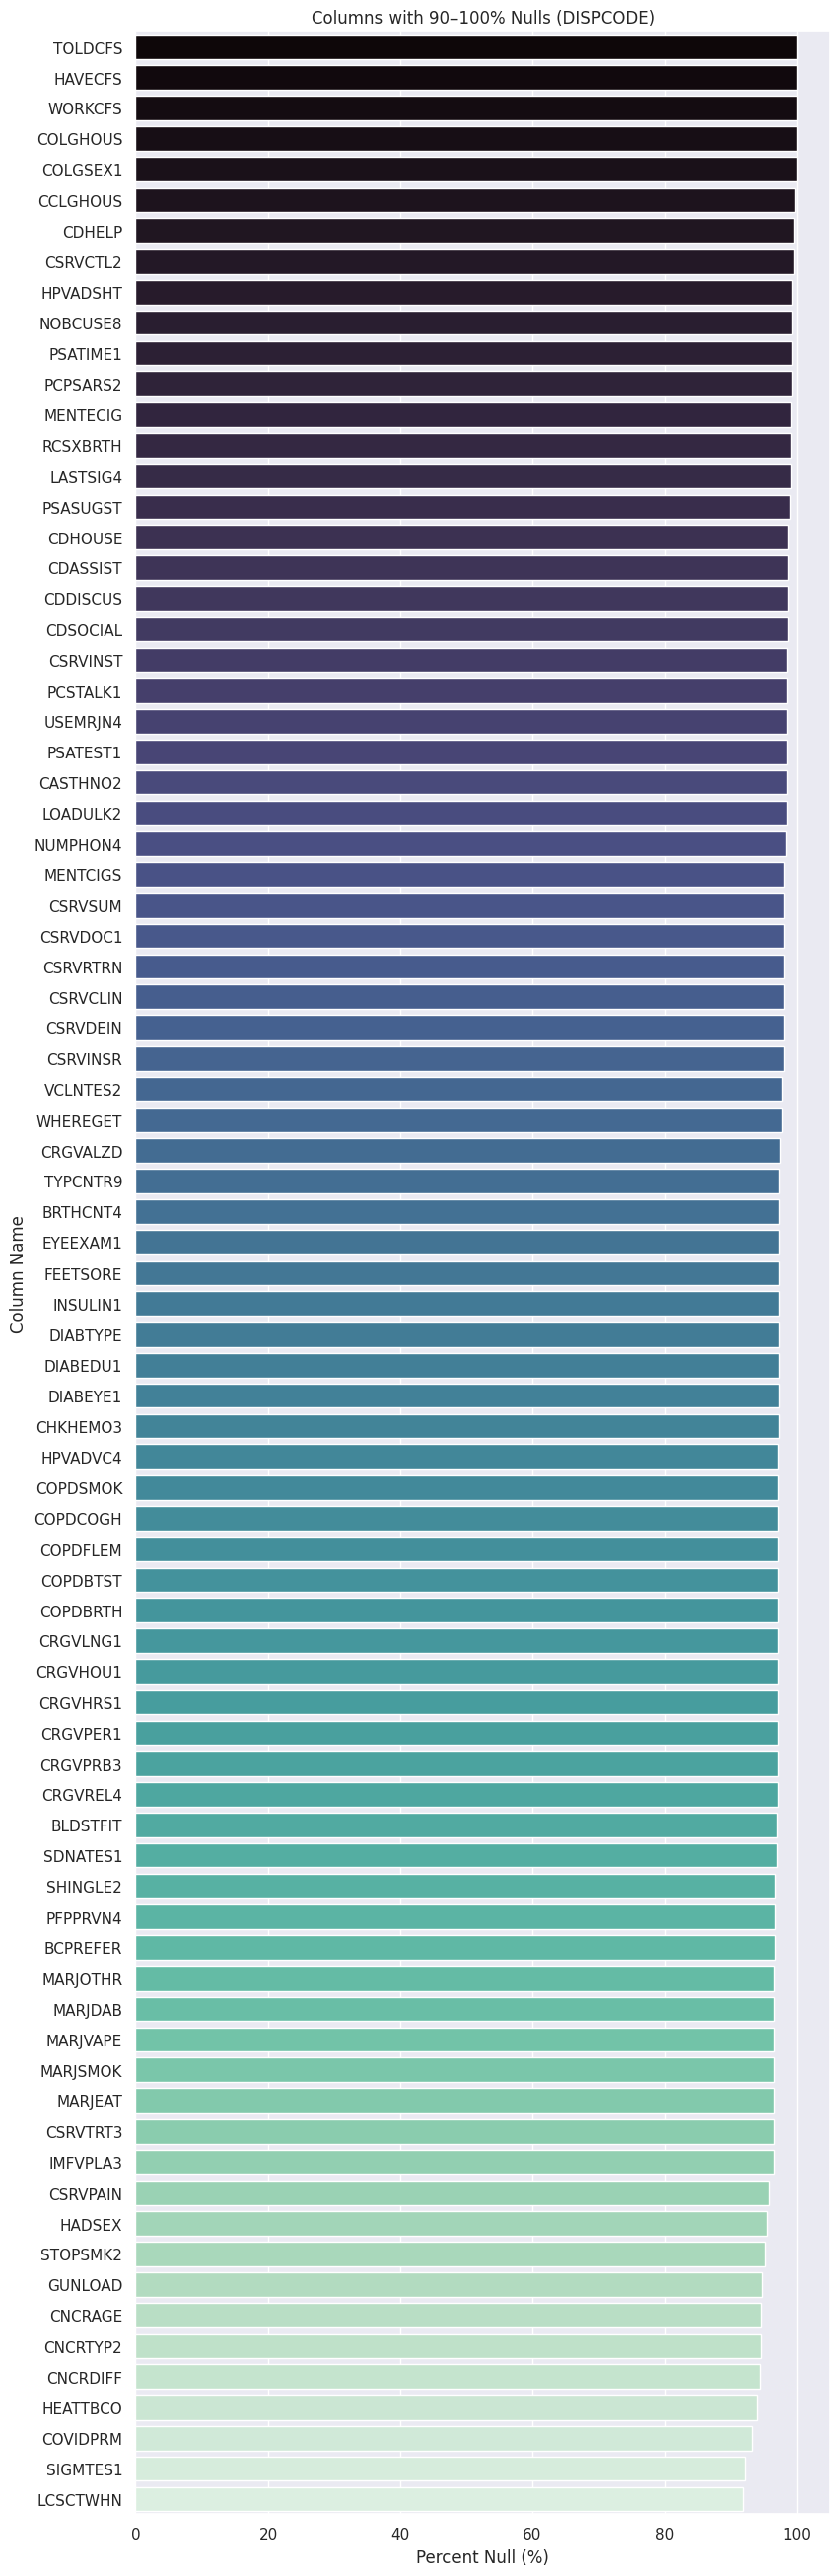

/tmp/ipython-input-1961566609.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Percent Null", y="Column", data=df_info_high_nulls, palette="mako")


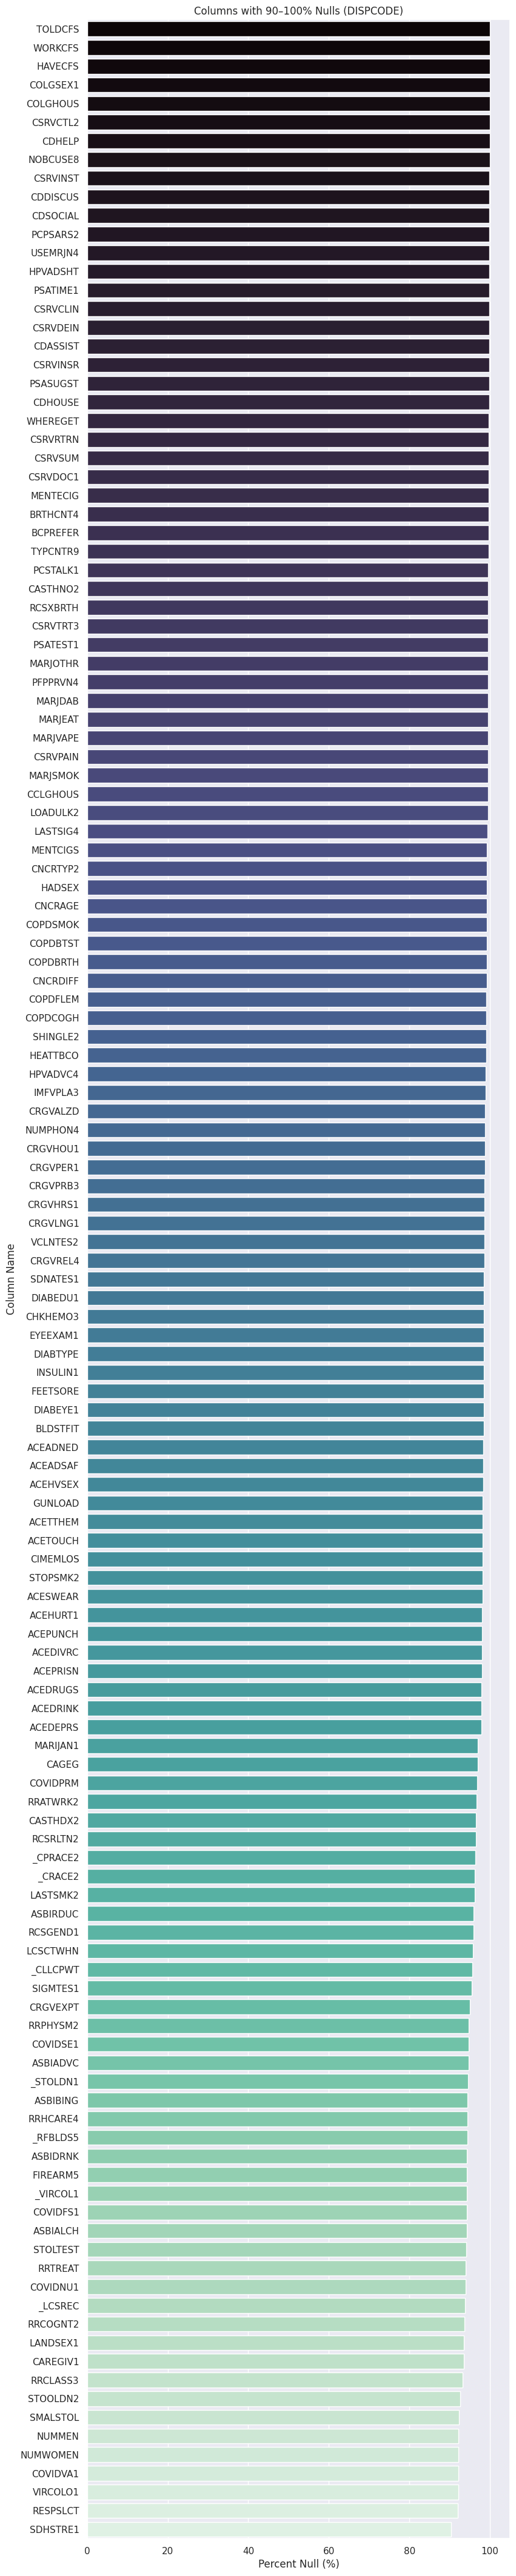

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = brfss  # your dataset

# Create a summary DataFrame for nulls
def plot_nulls_by_disposition(df, null_min=90, null_max=100):
    """
    Plots columns with high percentage of nulls (between null_min and null_max)
    for a given survey disposition code (DISPCODE).
    """
    df_filtered=df
    if df_filtered.empty:
        print(f"No rows found for DISPCODE")
        return

    # Create summary DataFrame
    df_info = pd.DataFrame({
        "Column": df_filtered.columns,
        "Nulls": df_filtered.isnull().sum(),
        "Non-Null": df_filtered.notnull().sum(),
        "Percent Null": df_filtered.isnull().mean() * 100
    })

    # Filter by null percentage range
    df_info_high_nulls = df_info[
        (df_info["Percent Null"] >= null_min) & (df_info["Percent Null"] <= null_max)
    ].sort_values(by="Percent Null", ascending=False)

    # Plot
    plt.figure(figsize=(9, len(df_info_high_nulls) * 0.4))
    sns.barplot(x="Percent Null", y="Column", data=df_info_high_nulls, palette="mako")
    plt.title(f"Columns with {null_min}–{null_max}% Nulls (DISPCODE)")
    plt.xlabel("Percent Null (%)")
    plt.ylabel("Column Name")
    plt.grid(True, axis='x')
    plt.show()

# Example: run for each status
# 1100	Completed Interview	353,271	79.36	72.20
# 1200	Partial Complete Interview	91,861	20.64	27.80


df_filtered_completed = df[df["DISPCODE"].isin([1100])]
df_filtered_partial = df[df["DISPCODE"].isin([1200])]
plot_nulls_by_disposition(df_filtered_completed)  # Completed Interview
plot_nulls_by_disposition(df_filtered_partial)  # Partial Complete Interview




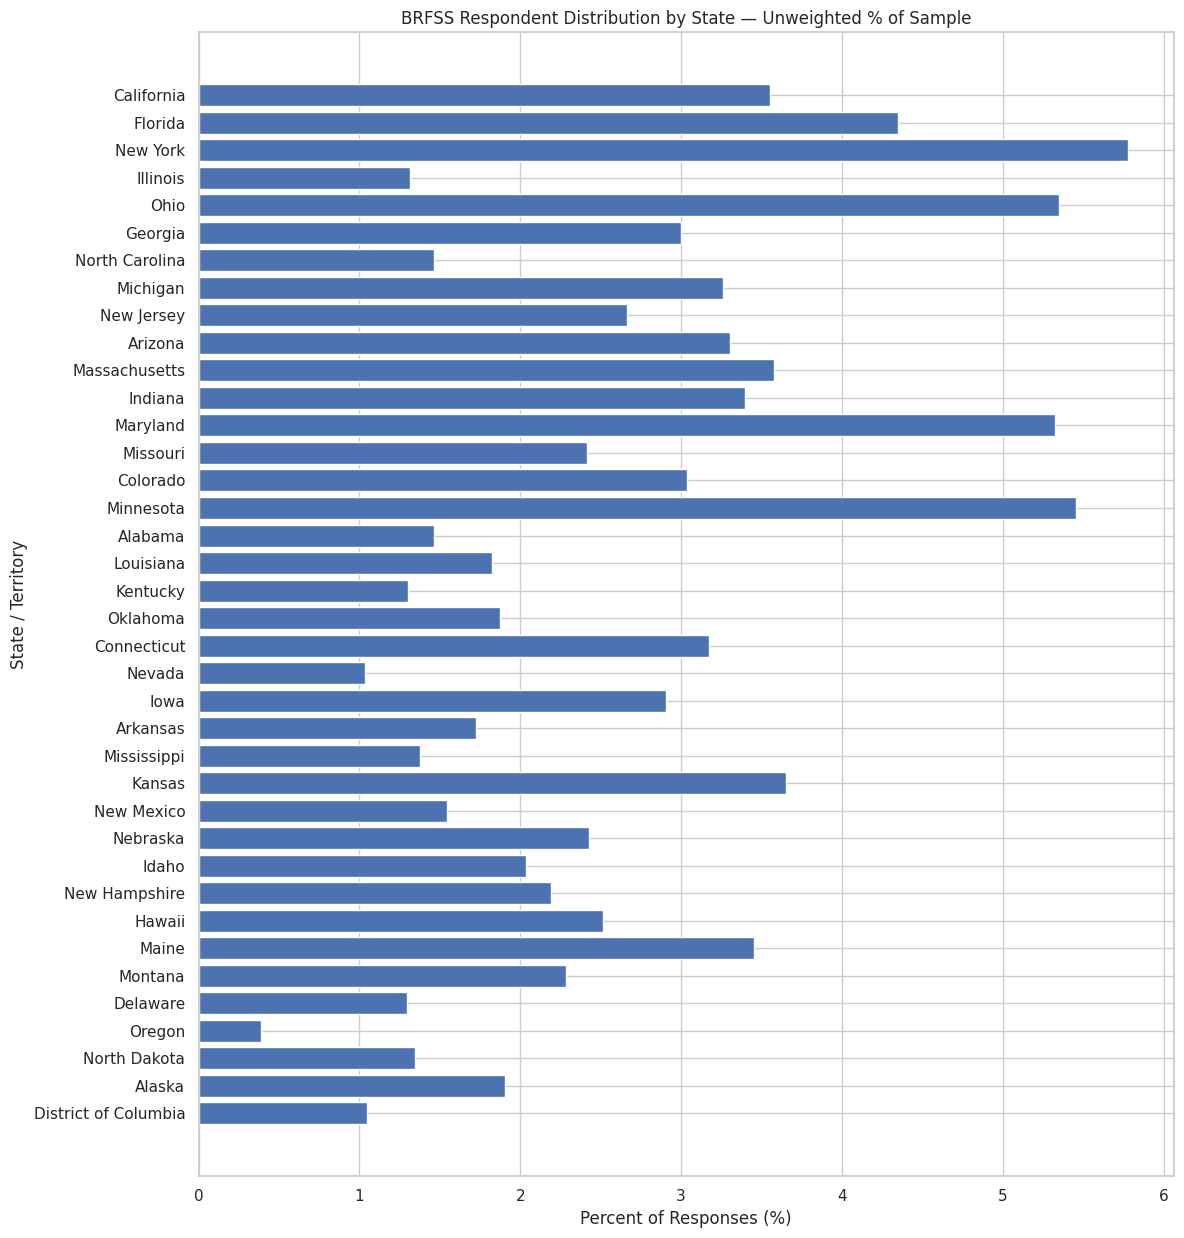

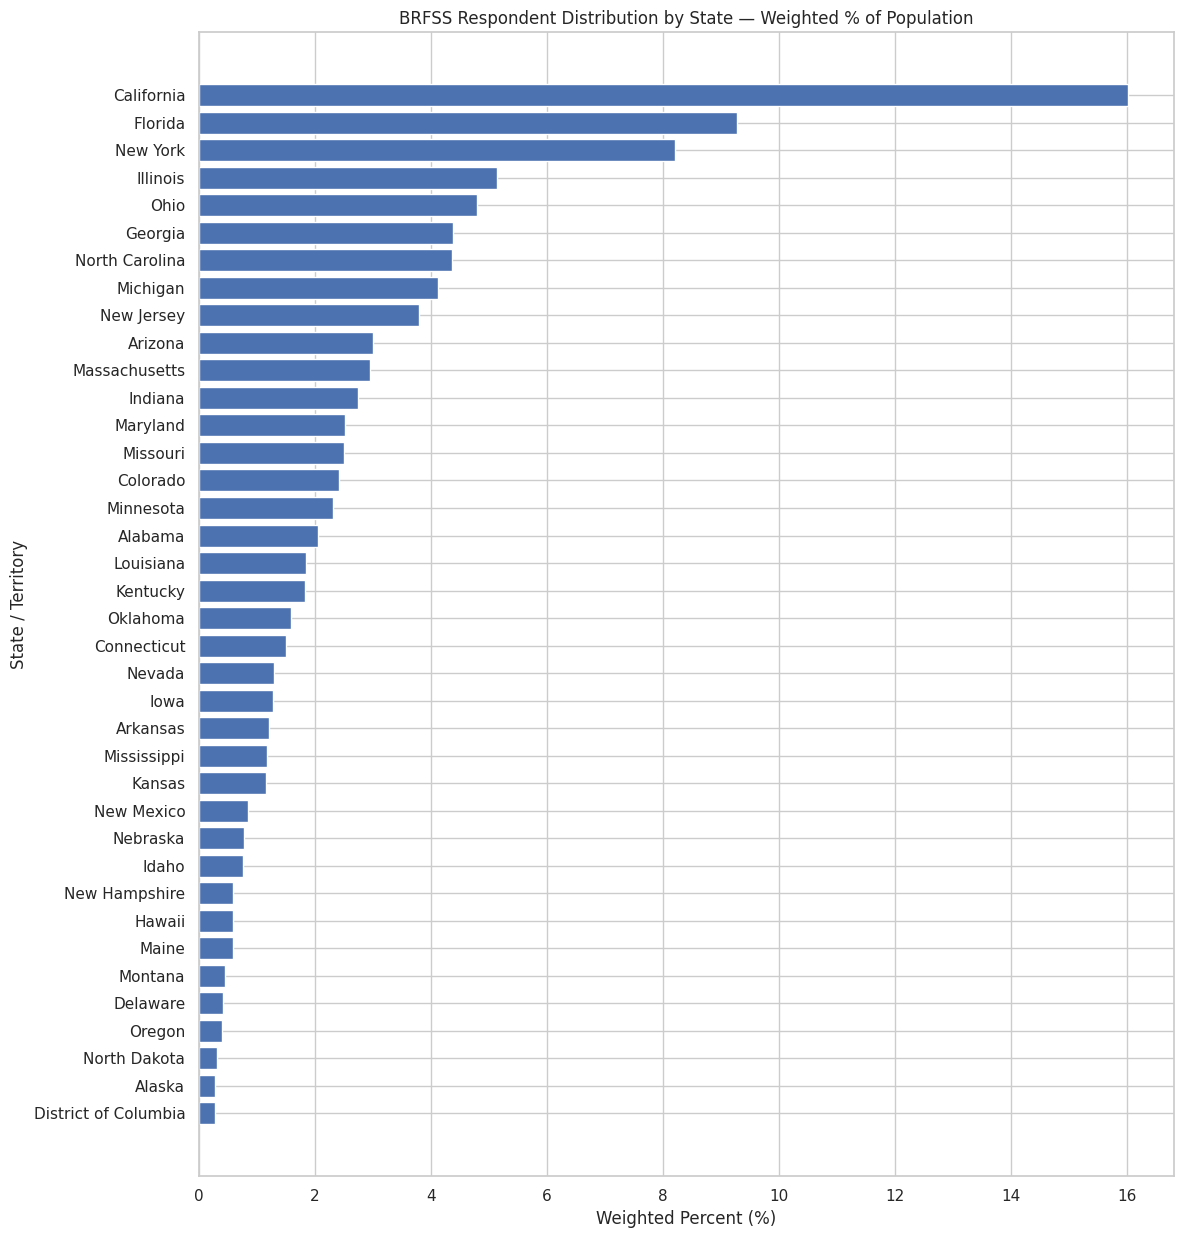

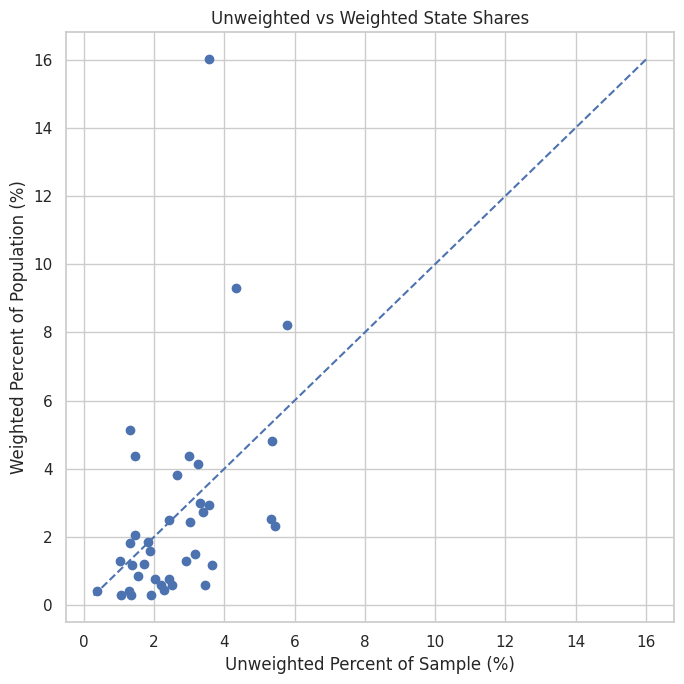

Most up-weighted (Weighted% >> Unweighted%):
          State  Unweighted_Percent  Weighted_Percent  Weight_Ratio
    California            3.553306         16.012000      4.506226
      Illinois            1.315943          5.146093      3.910574
North Carolina            1.461618          4.364340      2.985964
       Florida            4.345273          9.287395      2.137356
       Georgia            2.996561          4.385997      1.463677
    New Jersey            2.663357          3.807642      1.429640
      New York            5.775096          8.217933      1.422995
       Alabama            1.461943          2.061339      1.410000
      Kentucky            1.305237          1.832996      1.404340
      Michigan            3.263254          4.132153      1.266268

Most down-weighted (Weighted% << Unweighted%):
                State  Unweighted_Percent  Weighted_Percent  Weight_Ratio
              Alaska            1.902862          0.290116      0.152463
               Maine  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Your starting point ---
df = brfss.copy()  # must have columns: _STATE and _LLCPWT (the final weight)

# --- Build labels DataFrame from your table (as you did) ---
labels_data = [
    (1, "Alabama", "4,506", 1.01, 1.50),
    (2, "Alaska", "5,865", 1.32, 0.21),
    (4, "Arizona", "10,185", 2.29, 2.18),
    (5, "Arkansas", "5,309", 1.19, 0.89),
    (6, "California", "10,952", 2.46, 11.63),
    (8, "Colorado", "9,365", 2.10, 1.76),
    (9, "Connecticut", "9,784", 2.20, 1.09),
    (10, "Delaware", "3,987", 0.90, 0.30),
    (11, "District of Columbia", "3,237", 0.73, 0.21),
    (12, "Florida", "13,393", 3.01, 6.74),
    (13, "Georgia", "9,236", 2.07, 3.19),
    (15, "Hawaii", "7,747", 1.74, 0.43),
    (16, "Idaho", "6,280", 1.41, 0.56),
    (17, "Illinois", "4,056", 0.91, 3.74),
    (18, "Indiana", "10,466", 2.35, 1.99),
    (19, "Iowa", "8,949", 2.01, 0.94),
    (20, "Kansas", "11,247", 2.53, 0.85),
    (21, "Kentucky", "4,023", 0.90, 1.33),
    (22, "Louisiana", "5,629", 1.26, 1.35),
    (23, "Maine", "10,646", 2.39, 0.43),
    (24, "Maryland", "16,418", 3.69, 1.83),
    (25, "Massachusetts", "11,029", 2.48, 2.14),
    (26, "Michigan", "10,058", 2.26, 3.00),
    (27, "Minnesota", "16,821", 3.78, 1.68),
    (28, "Mississippi", "4,239", 0.95, 0.86),
    (29, "Missouri", "7,438", 1.67, 1.82),
    (30, "Montana", "7,048", 1.58, 0.33),
    (31, "Nebraska", "7,473", 1.68, 0.57),
    (32, "Nevada", "3,188", 0.72, 0.94),
    (33, "New Hampshire", "6,757", 1.52, 0.43),
    (34, "New Jersey", "8,209", 1.84, 2.77),
    (35, "New Mexico", "4,758", 1.07, 0.62),
    (36, "New York", "17,800", 4.00, 5.97),
    (37, "North Carolina", "4,505", 1.01, 3.17),
    (38, "North Dakota", "4,153", 0.93, 0.23),
    (39, "Ohio", "16,487", 3.70, 3.49),
    (40, "Oklahoma", "5,775", 1.30, 1.16),
    (41, "Oregon", "5,756", 1.29, 1.30),
    (42, "Pennsylvania", "4,582", 1.03, 3.91),
    (44, "Rhode Island", "5,893", 1.32, 0.34),
    (45, "South Carolina", "10,037", 2.25, 1.57),
    (46, "South Dakota", "7,424", 1.67, 0.26),
    (47, "Tennessee", "5,266", 1.18, 2.08),
    (48, "Texas", "14,245", 3.20, 8.52),
    (49, "Utah", "9,826", 2.21, 0.93),
    (50, "Vermont", "8,811", 1.98, 0.20),
    (51, "Virginia", "10,417", 2.34, 2.58),
    (53, "Washington", "26,152", 5.88, 2.33),
    (54, "West Virginia", "4,981", 1.12, 0.54),
    (55, "Wisconsin", "11,276", 2.53, 1.76),
    (56, "Wyoming", "4,142", 0.93, 0.17),
    (66, "Guam", "2,266", 0.51, 0.04),
    (72, "Puerto Rico", "5,509", 1.24, 1.11),
    (78, "Virgin Islands", "1,531", 0.34, 0.03),
]
labels_df = pd.DataFrame(
    labels_data,
    columns=["_STATE", "State", "Codebook_Frequency", "Codebook_Percentage", "Codebook_Weighted_Percentage"]
)
labels_df["Codebook_Frequency"] = labels_df["Codebook_Frequency"].str.replace(",", "", regex=False).astype(int)
labels_df["Codebook_Percentage"] = labels_df["Codebook_Percentage"].astype(float)
labels_df["Codebook_Weighted_Percentage"] = labels_df["Codebook_Weighted_Percentage"].astype(float)

# --- Unweighted counts/percents from your file ---
state_counts = (
    df.groupby("_STATE")
      .size()
      .reset_index(name="Count")
)
state_counts["Unweighted_Percent"] = 100 * state_counts["Count"] / state_counts["Count"].sum()

# --- Weighted totals/percents from your file (using final weight) ---
if "_LLCPWT" not in df.columns:
    raise ValueError("Weight variable _LLCPWT not found in df. Check your BRFSS year’s weight variable name.")

weighted_totals = (
    df.groupby("_STATE")["_LLCPWT"]
      .sum()
      .reset_index(name="Weighted_Total")
)
weighted_totals["Weighted_Percent"] = 100 * weighted_totals["Weighted_Total"] / weighted_totals["Weighted_Total"].sum()

# Optional: mean weight per state (how many people 1 respondent represents on average)
mean_weight = (
    df.groupby("_STATE")["_LLCPWT"]
      .mean()
      .reset_index(name="Mean_Weight")
)

# --- Join with labels for readable state names ---
out = (state_counts
       .merge(weighted_totals, on="_STATE", how="left")
       .merge(mean_weight, on="_STATE", how="left")
       .merge(labels_df[["_STATE","State","Codebook_Percentage","Codebook_Weighted_Percentage"]],
              on="_STATE", how="left")
      )

# Sort by weighted percent (top to bottom)
out = out.sort_values("Weighted_Percent", ascending=False).reset_index(drop=True)

# --- Plot 1: Unweighted percent (bar) ---
plt.figure(figsize=(12, max(6, 0.33*len(out))))
plt.barh(out["State"], out["Unweighted_Percent"])
plt.title("BRFSS Respondent Distribution by State — Unweighted % of Sample")
plt.xlabel("Percent of Responses (%)")
plt.ylabel("State / Territory")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- Plot 2: Weighted percent (bar) ---
plt.figure(figsize=(12, max(6, 0.33*len(out))))
plt.barh(out["State"], out["Weighted_Percent"])
plt.title("BRFSS Respondent Distribution by State — Weighted % of Population")
plt.xlabel("Weighted Percent (%)")
plt.ylabel("State / Territory")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- Plot 3: Unweighted vs Weighted (scatter) ---
plt.figure(figsize=(7,7))
plt.scatter(out["Unweighted_Percent"], out["Weighted_Percent"])
# 45-degree line for reference
mn = min(out["Unweighted_Percent"].min(), out["Weighted_Percent"].min())
mx = max(out["Unweighted_Percent"].max(), out["Weighted_Percent"].max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.title("Unweighted vs Weighted State Shares")
plt.xlabel("Unweighted Percent of Sample (%)")
plt.ylabel("Weighted Percent of Population (%)")
plt.tight_layout()
plt.show()

# (Optional) quick look at states most up-weighted/down-weighted
out["Weight_Ratio"] = out["Weighted_Percent"] / out["Unweighted_Percent"]
up_weighted = out.sort_values("Weight_Ratio", ascending=False)[["State","Unweighted_Percent","Weighted_Percent","Weight_Ratio"]].head(10)
down_weighted = out.sort_values("Weight_Ratio", ascending=True)[["State","Unweighted_Percent","Weighted_Percent","Weight_Ratio"]].head(10)
print("Most up-weighted (Weighted% >> Unweighted%):\n", up_weighted.to_string(index=False))
print("\nMost down-weighted (Weighted% << Unweighted%):\n", down_weighted.to_string(index=False))


In [ ]:
# missing data for each column - maybe create a graph to show distribution
missing_data = pd.DataFrame({
    'column': brfss.columns,
    'missing_count': brfss.isnull().sum().values,
    'missing_percent': (brfss.isnull().sum().values / len(brfss) * 100)
    })

missing_data = missing_data.sort_values('missing_percent', ascending=False)
print(missing_data)

       column  missing_count  missing_percent
131   WORKCFS         308220       100.000000
129   TOLDCFS         308220       100.000000
130   HAVECFS         308220       100.000000
11   COLGHOUS         308203        99.994484
15   COLGSEX1         308201        99.993836
..        ...            ...              ...
5       IYEAR              0         0.000000
2       IDATE              0         0.000000
31     SEXVAR              0         0.000000
1      FMONTH              0         0.000000
0      _STATE              0         0.000000

[326 rows x 3 columns]


In [ ]:
brfss.describe(include = "all")

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_SMOKGRP,_LCSREC,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK2,_RFDRHV8,_FLSHOT7,_PNEUMO3,_AIDTST4
count,308220.000000,308220.000000,3.082200e+05,308220.000000,308220.000000,308220.000000,308220.000000,3.082200e+05,3.082200e+05,66101.000000,...,283112.000000,36332.000000,308219.000000,3.082160e+05,308219.000000,3.082190e+05,308219.000000,116888.000000,116888.000000,275299.000000
mean,22.103631,6.741185,6.846321e+06,6.689812,15.448686,2022.051187,1121.339628,2.022005e+09,2.022005e+09,1.000030,...,3.447406,1.901932,2.258663,1.117572e+02,2.070878,1.167946e+04,1.972146,2.396533,2.577382,2.024152
std,11.045340,3.528157,3.539833e+06,3.534382,8.524269,0.220380,40.970581,3.854077e+03,3.854077e+03,0.005501,...,0.809022,0.297410,2.339996,2.744780e+02,2.553495,3.169094e+04,2.534455,2.723316,2.915166,1.659067
min,1.000000,1.000000,1.012023e+06,1.000000,0.000000,2022.000000,1100.000000,2.022000e+09,2.022000e+09,1.000000,...,1.000000,1.000000,1.000000,5.397605e-79,1.000000,5.397605e-79,1.000000,1.000000,1.000000,1.000000
25%,13.000000,4.000000,4.012022e+06,4.000000,8.000000,2022.000000,1100.000000,2.022002e+09,2.022002e+09,1.000000,...,3.000000,2.000000,1.000000,5.397605e-79,1.000000,5.397605e-79,1.000000,1.000000,1.000000,1.000000
50%,23.000000,7.000000,7.112022e+06,7.000000,15.000000,2022.000000,1100.000000,2.022004e+09,2.022004e+09,1.000000,...,4.000000,2.000000,2.000000,7.000000e+00,1.000000,4.700000e+01,1.000000,1.000000,1.000000,2.000000
75%,31.000000,10.000000,1.011202e+07,10.000000,22.000000,2022.000000,1100.000000,2.022007e+09,2.022007e+09,1.000000,...,4.000000,2.000000,2.000000,4.300000e+01,1.000000,6.000000e+02,1.000000,2.000000,2.000000,2.000000
max,41.000000,12.000000,1.231202e+07,12.000000,31.000000,2023.000000,1200.000000,2.022018e+09,2.022018e+09,2.000000,...,4.000000,2.000000,9.000000,9.000000e+02,9.000000,9.990000e+04,9.000000,9.000000,9.000000,9.000000


In [ ]:
#Showing completed surveys vs partially completed surveys
dispo_counts = brfss['DISPCODE'].value_counts().loc[[1100, 1200]]


freq_table = dispo_counts.reset_index()
freq_table.columns = ['DISPCODE', 'Frequency']

# Map value labels
value_labels = {1100: 'Completed Interview', 1200: 'Partial Complete Interview'}
freq_table['Label'] = freq_table['DISPCODE'].map(value_labels)


freq_table['Proportion'] = freq_table['Frequency'] / freq_table['Frequency'].sum()

print(freq_table)

   DISPCODE  Frequency                       Label  Proportion
0    1100.0     242447         Completed Interview    0.786604
1    1200.0      65773  Partial Complete Interview    0.213396


In [ ]:
## demographics - graph distributions???
summary_demographics = brfss[['_AGEG5YR', 'EMPLOY1', '_INCOMG1', '_EDUCAG', '_RACE1', 'EXERANY2', '_MENT14D']].describe()
summary_demographics.loc['median'] = brfss[['_AGEG5YR', 'EMPLOY1', '_INCOMG1', '_EDUCAG', '_RACE1', 'EXERANY2', '_MENT14D']].median()
summary_demographics

,_AGEG5YR,EMPLOY1,_INCOMG1,_EDUCAG,_RACE1,EXERANY2,_MENT14D
count,308219.000000,303850.000000,308219.000000,308219.000000,308218.000000,308217.000000,308219.000000
mean,7.749931,3.861863,5.417586,3.090406,2.224286,1.258341,1.682473
std,3.681039,2.899165,2.363004,1.041445,2.469617,0.538058,1.280296
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,5.000000,1.000000,4.000000,2.000000,1.000000,1.000000,1.000000
50%,8.000000,2.000000,5.000000,3.000000,1.000000,1.000000,1.000000
75%,11.000000,7.000000,7.000000,4.000000,2.000000,1.000000,2.000000
max,14.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
median,8.000000,2.000000,5.000000,3.000000,1.000000,1.000000,1.000000


In [ ]:
brfss['BIRTHSEX_LABEL'] = brfss['BIRTHSEX'].replace({
    1: 'Male',
    2: 'Female',
    7: "Don't know / Not sure",
    9: 'Refused'
})

#  Count how many of each category (including missing)
birthsex_counts = brfss['BIRTHSEX_LABEL'].value_counts(dropna=False)

birthsex_summary = pd.DataFrame({
    'Response': birthsex_counts.index,
    'Count': birthsex_counts.values
})

birthsex_summary['Percent'] = (birthsex_summary['Count'] / len(brfss) * 100).round(2)

print(birthsex_summary)

                Response   Count  Percent
0                    NaN  251860    81.71
1                 Female   29380     9.53
2                   Male   26548     8.61
3                Refused     360     0.12
4  Don't know / Not sure      72     0.02


In [ ]:
age_map = {
    1: "Age 18 to 24", 2: "Age 25 to 29", 3: "Age 30 to 34", 4: "Age 35 to 39",
    5: "Age 40 to 44", 6: "Age 45 to 49", 7: "Age 50 to 54", 8: "Age 55 to 59",
    9: "Age 60 to 64", 10: "Age 65 to 69", 11: "Age 70 to 74", 12: "Age 75 to 79",
    13: "Age 80 or older", 14: "Don’t know/Refused/Missing"
}

employ_map = {
    1: "Employed for wages", 2: "Self-employed", 3: "Out of work ≥1 year",
    4: "Out of work <1 year", 5: "Homemaker", 6: "Student",
    7: "Retired", 8: "Unable to work", 9: "Refused"
}

income_map = {
    1: "Less than $15,000", 2: "$15k–<$25k", 3: "$25k–<$35k",
    4: "$35k–<$50k", 5: "$50k–<$100k", 6: "$100k–<$200k",
    7: "$200k+", 9: "Don’t know/Missing"
}

educ_map = {
    1: "Did not graduate HS", 2: "Graduated HS",
    3: "Attended college/tech school", 4: "Graduated college/tech school",
    9: "Don’t know/Missing"
}

race_map = {
    1: "White, non-Hispanic", 2: "Black, non-Hispanic",
    3: "American Indian/Alaska Native, non-Hispanic",
    4: "Asian, non-Hispanic", 5: "Native Hawaiian/Pacific Islander, non-Hispanic",
    7: "Multiracial, non-Hispanic", 8: "Hispanic",
    9: "Don’t know/Refused/Missing"
}

mental_map = {
    1: "Zero days poor mental health",
    2: "1–13 days poor mental health",
    3: "14+ days poor mental health",
    9: "Don’t know/Refused/Missing"
}

exercise_map = {
    1: "Yes",
    2: "No",
    3: "Don’t know/Not Sure",
    9: "Refused/Missing"
}

In [ ]:
mapping_dict = {
    '_AGEG5YR_label': age_map,
    'EMPLOY1_label': employ_map,
    '_INCOMG1_label': income_map,
    '_EDUCAG_label': educ_map,
    '_RACE1_label': race_map,
    '_MENT14D_label': mental_map,
    'EXERANY2_label': exercise_map}

In [ ]:
for col, value_map in mapping_dict.items():
    # original numeric column/value
    num_col = col.replace("_label", "")

    # Map numeric codes to labels
    mapped = brfss[num_col].map(lambda x: value_map.get(x, "Other"))


    freq_table = mapped.value_counts().reset_index()
    freq_table.columns = ['Value Label', 'Frequency']


    freq_table['Percent'] = (freq_table['Frequency'] / freq_table['Frequency'].sum() * 100).round(2)

    print(f"\n--- {col.upper()} ---")
    print(freq_table)


--- _AGEG5YR_LABEL ---
                   Value Label  Frequency  Percent
0                 Age 65 to 69      32659    10.60
1                 Age 60 to 64      30702     9.96
2                 Age 70 to 74      30053     9.75
3                 Age 55 to 59      25562     8.29
4              Age 80 or older      25420     8.25
5                 Age 50 to 54      23023     7.47
6                 Age 75 to 79      22400     7.27
7                 Age 40 to 44      20500     6.65
8                 Age 35 to 39      19620     6.37
9                 Age 45 to 49      19418     6.30
10                Age 18 to 24      19202     6.23
11                Age 30 to 34      17986     5.84
12                Age 25 to 29      15318     4.97
13  Don’t know/Refused/Missing       6356     2.06
14                       Other          1     0.00

--- EMPLOY1_LABEL ---
           Value Label  Frequency  Percent
0   Employed for wages     128899    41.82
1              Retired      94942    30.80
2       

In [ ]:
##how to show proportion as well
## Value	Value Label
## 1	Zero days when mental health not good
## 2	1-13 days when mental health not good
## 3	14+ days when mental health not good
## 9	Don’t know/Refused/Missing
brfss.groupby('_AGEG5YR')['_MENT14D'].agg(['median', 'min', 'max'])

,median,min,max
_AGEG5YR,,,
1.0,2.0,1.0,9.0
2.0,2.0,1.0,9.0
3.0,2.0,1.0,9.0
4.0,2.0,1.0,9.0
5.0,1.0,1.0,9.0
6.0,1.0,1.0,9.0
7.0,1.0,1.0,9.0
8.0,1.0,1.0,9.0
9.0,1.0,1.0,9.0


In [ ]:
brfss.groupby('_INCOMG1')['_MENT14D'].agg(['median', 'min', 'max'])

,median,min,max
_INCOMG1,,,
1.0,2.0,1.0,9.0
2.0,1.0,1.0,9.0
3.0,1.0,1.0,9.0
4.0,1.0,1.0,9.0
5.0,1.0,1.0,9.0
6.0,1.0,1.0,9.0
7.0,1.0,1.0,9.0
9.0,1.0,1.0,9.0


In [ ]:
brfss.groupby('_EDUCAG')['_MENT14D'].agg(Frequency='count',Median='median', Min='min',Max='max').reset_index()

,_EDUCAG,Frequency,Median,Min,Max
0,1.0,17926,1.0,1.0,9.0
1,2.0,75842,1.0,1.0,9.0
2,3.0,83177,1.0,1.0,9.0
3,4.0,129617,1.0,1.0,9.0
4,9.0,1657,1.0,1.0,9.0


In [ ]:
brfss.groupby('_RACE1')['_MENT14D'].agg(['median', 'min', 'max'])

,median,min,max
_RACE1,,,
1.0,1.0,1.0,9.0
2.0,1.0,1.0,9.0
3.0,1.0,1.0,9.0
4.0,1.0,1.0,9.0
5.0,1.0,1.0,9.0
7.0,2.0,1.0,9.0
8.0,1.0,1.0,9.0
9.0,1.0,1.0,9.0


In [ ]:
brfss.groupby('EXERANY2')['_MENT14D'].agg(['median', 'min', 'max'])

,median,min,max
EXERANY2,,,
1.0,1.0,1.0,9.0
2.0,1.0,1.0,9.0
7.0,1.0,1.0,9.0
9.0,1.0,1.0,9.0


In [ ]:
brfss.shape

(308220, 327)

In [ ]:
freq_table = pd.crosstab(
    brfss['_AGEG5YR'],
    brfss['_MENT14D'],
    dropna=False
)

print("Frequency Table:")
print(freq_table)

Frequency Table:
_MENT14D    1.0   2.0   3.0  9.0  NaN
_AGEG5YR                             
1.0        6730  7447  4629  396    0
2.0        5997  5892  3164  265    0
3.0        7838  6350  3454  344    0
4.0        9415  6460  3413  332    0
5.0       10426  6378  3378  318    0
6.0       10610  5466  3007  335    0
7.0       13084  6093  3451  395    0
8.0       15379  6096  3624  463    0
9.0       19919  6488  3718  577    0
10.0      22636  6206  3166  651    0
11.0      21417  5424  2597  615    0
12.0      16553  3616  1730  501    0
13.0      19565  3418  1606  831    0
14.0       4288  1103   644  321    0
NaN           0     0     0    0    1


In [ ]:
import matplotlib.pyplot as plt

# Pivot for heatmap
hp = agg.pivot(index="_STATE", columns="INCOME2", values="Fair/Poor %")
hm = agg.pivot(index="_STATE", columns="INCOME2", values="MentDistress ≥14d %")

# Plot A
plt.figure(figsize=(10,12))
plt.imshow(hp.values, aspect='auto')
plt.yticks(range(len(hp.index)), hp.index)
plt.xticks(range(len(hp.columns)), [income_labels.get(int(c), c) for c in hp.columns], rotation=45, ha="right")
plt.colorbar(label='%')
plt.title('Fair/Poor Health by State × Income (Weighted, BRFSS 2022)')
plt.tight_layout(); plt.show()

# Plot B
plt.figure(figsize=(10,12))
plt.imshow(hm.values, aspect='auto')
plt.yticks(range(len(hm.index)), hm.index)
plt.xticks(range(len(hm.columns)), [income_labels.get(int(c), c) for c in hm.columns], rotation=45, ha="right")
plt.colorbar(label='%')
plt.title('Frequent Mental Distress (≥14d) by State × Income (Weighted, BRFSS 2022)')
plt.tight_layout(); plt.show()


NameError: name 'agg' is not defined

In [ ]:
!pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=3ec1dd92fa6443f2b088bcd0b28fe43da7c4f7c153093dcc3c91272f9ebf2cf1
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.colors as mcolors
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Polygon
import missingno as msno
import os
import wget
import openpyxl
import math

# 1️⃣ Install geopandas stack (only once per session)
!pip -q install geopandas shapely fiona pyproj rtree

# 2️⃣ Imports
import geopandas as gpd
import wget, os
import matplotlib.pyplot as plt

# 3️⃣ Download the shapefile (only once)
wget.download("https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_500k.zip")

# 4️⃣ Unzip it
import zipfile
with zipfile.ZipFile("cb_2018_us_state_500k.zip", "r") as zip_ref:
    zip_ref.extractall("cb_2018_us_state_500k")

# 5️⃣ Load shapefile with GeoPandas
gdf = gpd.read_file("cb_2018_us_state_500k/cb_2018_us_state_500k.shp")
print(gdf.head())
print(gdf.columns)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.6/507.6 kB 19.6 MB/s eta 0:00:00
  STATEFP   STATENS     AFFGEOID GEOID STUSPS            NAME LSAD  \
0      28  01779790  0400000US28    28     MS     Mississippi   00   
1      37  01027616  0400000US37    37     NC  North Carolina   00   
2      40  01102857  0400000US40    40     OK        Oklahoma   00   
3      51  01779803  0400000US51    51     VA        Virginia   00   
4      54  01779805  0400000US54    54     WV   West Virginia   00   

          ALAND       AWATER  \
0  121533519481   3926919758   
1  125923656064  13466071395   
2  177662925723   3374587997   
3  102257717110   8528531774   
4   62266474513    489028543   

                                            geometry  
0  MULTIPOLYGON (((-88.50297 30.21524, -88.49176 ...  
1  MULTIPOLYGON (((-75.72681 35.9358

<Figure size 1000x600 with 0 Axes>

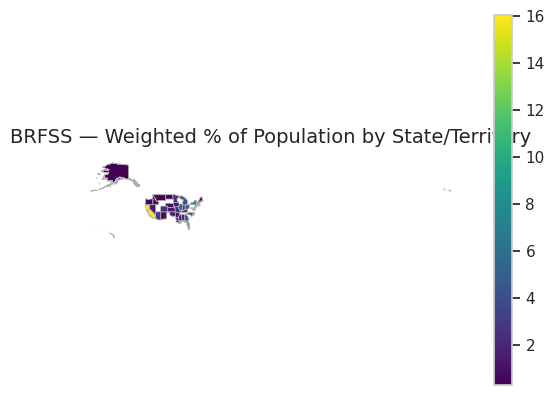

<Figure size 1200x700 with 0 Axes>

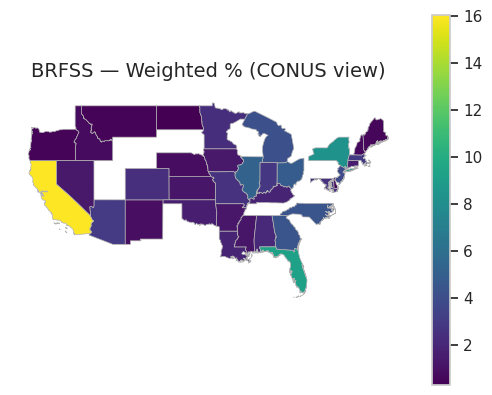

In [ ]:
# 0) Colab installs (GeoPandas stack)
!pip -q install geopandas shapely fiona pyproj rtree

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 1) Your 'out' dataframe exists already from your code above and contains:
#    columns like ["State", "Unweighted_Percent", "Weighted_Percent", ...]
#    If you don't have 'State' yet, merge from labels_df first:
# out = out.merge(labels_df[["_STATE","State"]], on="_STATE", how="left")

# 2) Map state names -> USPS (STUSPS) so we can merge with the Natural Earth 'postal' column
name_to_usps = {
    "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA",
    "Colorado":"CO","Connecticut":"CT","Delaware":"DE","District of Columbia":"DC",
    "Florida":"FL","Georgia":"GA","Hawaii":"HI","Idaho":"ID","Illinois":"IL",
    "Indiana":"IN","Iowa":"IA","Kansas":"KS","Kentucky":"KY","Louisiana":"LA",
    "Maine":"ME","Maryland":"MD","Massachusetts":"MA","Michigan":"MI","Minnesota":"MN",
    "Mississippi":"MS","Missouri":"MO","Montana":"MT","Nebraska":"NE","Nevada":"NV",
    "New Hampshire":"NH","New Jersey":"NJ","New Mexico":"NM","New York":"NY",
    "North Carolina":"NC","North Dakota":"ND","Ohio":"OH","Oklahoma":"OK","Oregon":"OR",
    "Pennsylvania":"PA","Rhode Island":"RI","South Carolina":"SC","South Dakota":"SD",
    "Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT","Virginia":"VA",
    "Washington":"WA","West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY",
    # Territories in your table:
    "Puerto Rico":"PR","Guam":"GU","Virgin Islands":"VI"
}

out_map = out.copy()
out_map["STUSPS"] = out_map["State"].map(name_to_usps)

# 3) Read Natural Earth Admin-1 (states/provinces) directly via URL and keep USA
url_admin1 = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_admin_1_states_provinces.geojson"
adm1 = gpd.read_file(url_admin1)
adm1_usa = adm1.loc[adm1["admin"]=="United States of America", ["name","postal","geometry"]].copy()
adm1_usa.rename(columns={"name":"State_NE","postal":"STUSPS"}, inplace=True)

# 4) Merge shapes with your data (left=geometries to keep all states even if missing values)
gdf = adm1_usa.merge(out_map[["STUSPS","State","Unweighted_Percent","Weighted_Percent"]],
                     on="STUSPS", how="left")

# 5) Plot WEIGHTED percent (swap to 'Unweighted_Percent' if desired)
plt.figure(figsize=(10,6))
ax = gdf.plot(column="Weighted_Percent",
              cmap="viridis",
              linewidth=0.5,
              edgecolor="0.7",
              legend=True)
ax.set_title("BRFSS — Weighted % of Population by State/Territory", fontsize=14, pad=12)
ax.axis("off")
plt.show()

# Optional: CONUS-only view (zoom to continental US bounding box)
# (You can tweak bounds if needed)
conus = gdf.cx[-130:-65, 24:50]   # lon_min:lon_max, lat_min:lat_max
plt.figure(figsize=(32,37))
ax = conus.plot(column="Weighted_Percent", cmap="viridis", linewidth=0.5, edgecolor="0.7", legend=True)
ax.set_title("BRFSS — Weighted % (CONUS view)", fontsize=14, pad=12)
ax.axis("off")
plt.show()

<Figure size 3200x3700 with 0 Axes>

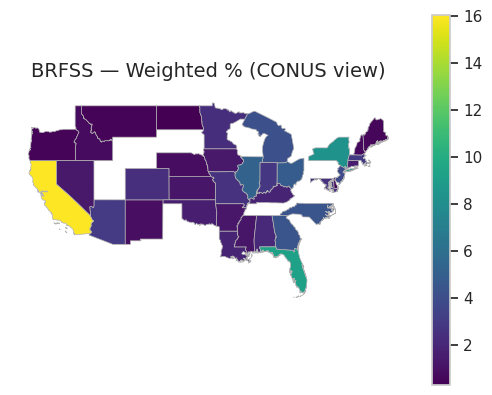

<Axes: >

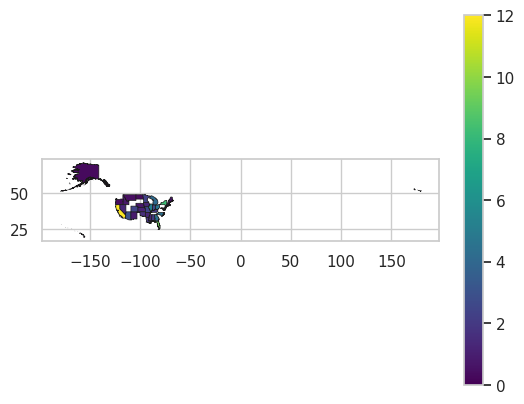

In [ ]:

conus = gdf.cx[-130:-65, 24:50]   # lon_min:lon_max, lat_min:lat_max
plt.figure(figsize=(32,37))
ax = conus.plot(column="Weighted_Percent", cmap="viridis", linewidth=0.5, edgecolor="0.7", legend=True)
ax.set_title("BRFSS — Weighted % (CONUS view)", fontsize=14, pad=12)
ax.axis("off")
plt.show()

vmin, vmax = 0, 12  # adjust to your dataset range
gdf.plot(column="Weighted_Percent", cmap="viridis", legend=True,
         linewidth=0.5, edgecolor="0.1", vmin=vmin, vmax=vmax)


In [ ]:
#without missing values
brfss_clean = brfss[(brfss['_AGEG5YR'] != 14) & (brfss['_MENT14D'] != 9)]
counts_age = pd.crosstab(brfss_clean['_AGEG5YR'], brfss_clean['_MENT14D'])
row_totals_age = counts_age.sum(axis=1)
prop_table_age = (counts_age.div(row_totals_age, axis=0) * 100).round(2)
print("Proportion Table (% within age group):")
print(prop_table_age)

In [ ]:
age_labels = {
    1: "Age 18-24", 2: "Age 25-29", 3: "Age 30-34", 4: "Age 35-39",
    5: "Age 40-44", 6: "Age 45-49", 7: "Age 50-54", 8: "Age 55-59",
    9: "Age 60-64", 10: "Age 65-69", 11: "Age 70-74", 12: "Age 75-79",
    13: "Age 80+"
}
mental_labels = {
    1: "0 days poor MH",
    2: "1-13 days poor MH",
    3: "14+ days poor MH",
}
prop_table_age.index = prop_table_age.index.map(age_labels)
prop_table_age.columns = prop_table_age.columns.map(mental_labels)

prop_table_age = prop_table_age.iloc[::-1] # have the youngest age at the top and missing at the very bottom

prop_table_age.plot(kind='barh', stacked=True, figsize=(10, 8))
plt.title('Mental Health Status by Age Group')
plt.xlabel('Percentage (%)')
plt.ylabel('Age Group')
plt.legend(title='Mental Health (14 days)', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [ ]:
counts_edu = pd.crosstab(brfss['_EDUCAG'], brfss['_MENT14D'])
row_totals_edu = counts_edu.sum(axis=1)
prop_table_edu = (counts_edu.div(row_totals_edu, axis=0) * 100).round(2)
print("Proportion Table (% within education group):")
print(prop_table_edu)

In [ ]:
educ_labels = {
    1: "Did not graduate HS", 2: "Graduated HS",
    3: "Attended college/uni/tech school", 4: "Graduated college/uni/tech school",
    9: "Don’t know/Missing"
}

mental_labels = {
    1: "0 days poor MH",
    2: "1-13 days poor MH",
    3: "14+ days poor MH",
    9: "Missing"
}
prop_table_edu.index = prop_table_edu.index.map(educ_labels)
prop_table_edu.columns = prop_table_edu.columns.map(mental_labels)

prop_table_edu = prop_table_edu.iloc[::-1]

prop_table_edu.plot(kind='barh', stacked=True, figsize=(10, 8))
plt.title('Mental Health Status by Education level')
plt.xlabel('Percentage (%)')
plt.ylabel('Education level')
plt.legend(title='Mental Health Scores', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [ ]:
#no missing values
counts_employ = pd.crosstab(brfss['EMPLOY1'], brfss['_MENT14D'])
row_totals_employ = counts_employ.sum(axis=1)
prop_table_employ = (counts_employ.div(row_totals_employ, axis=0) * 100).round(2)
print("Proportion Table (% within employment status):")
print(prop_table_employ)

In [ ]:
employ_labels = {
    1: "Employed for wages", 2: "Self-employed", 3: "Out of work ≥1 year",
    4: "Out of work <1 year", 5: "Homemaker", 6: "Student",
    7: "Retired", 8: "Unable to work", 9: "Refused"
}

mental_labels = {
    1: "0 days poor MH",
    2: "1-13 days poor MH",
    3: "14+ days poor MH",
    9: "Missing"
}
prop_table_employ.index = prop_table_employ.index.map(employ_labels)
prop_table_employ.columns = prop_table_employ.columns.map(mental_labels)

prop_table_employ = prop_table_employ.iloc[::-1]

prop_table_employ.plot(kind='barh', stacked=True, figsize=(10, 8))
plt.title('Mental Health Status by Employment status')
plt.xlabel('Percentage (%)')
plt.ylabel('Employment status')
plt.legend(title='Mental Health Scores', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [ ]:
#no missing values
counts_race = pd.crosstab(brfss['_RACE1'], brfss['_MENT14D'])
row_totals_race = counts_race.sum(axis=1)
prop_table_race = (counts_race.div(row_totals_race, axis=0) * 100).round(2)
print("Proportion Table (% within race category):")
print(prop_table_race)

In [ ]:
race_labels = {
    1: "White", 2: "Black",
    3: "American Indian/Alaska Native",
    4: "Asian", 5: "Native Hawaiian/Pacific Islander",
    7: "Multiracial", 8: "Hispanic",
    9: "Don’t know/Refused/Missing"
}

mental_labels = {
    1: "0 days poor MH",
    2: "1-13 days poor MH",
    3: "14+ days poor MH",
    9: "Missing"
}
prop_table_race.index = prop_table_race.index.map(race_labels)
prop_table_race.columns = prop_table_race.columns.map(mental_labels)

prop_table_race = prop_table_race.iloc[::-1]

prop_table_race.plot(kind='barh', stacked=True, figsize=(10, 8))
plt.title('Mental Health Status by Race')
plt.xlabel('Percentage (%)')
plt.ylabel('Race')
plt.legend(title='Mental Health Scores', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [ ]:
#Showing completed surveys vs partially completed surveys
dispo_counts = brfss['DISPCODE'].value_counts().loc[[1100, 1200]]

freq_table = dispo_counts.reset_index()
freq_table.columns = ['DISPCODE', 'Frequency']

value_labels = {1100: 'Completed Interview', 1200: 'Partial Complete Interview'}
freq_table['Label'] = freq_table['DISPCODE'].map(value_labels)


freq_table['Proportion'] = freq_table['Frequency'] / freq_table['Frequency'].sum()

print(freq_table)

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(freq_table['Frequency'],
        labels=freq_table['Label'],
        autopct='%1.1f%%',
        startangle=270)
plt.title('Survey Completion Status')
plt.show()

In [ ]:
counts_sex = pd.crosstab(brfss['SEXVAR'], brfss['_MENT14D'])
row_totals_sex = counts_sex.sum(axis=1)
prop_table_sex = (counts_sex.div(row_totals_sex, axis=0) * 100).round(2)
print("Proportion Table (% within sex category):")
print(prop_table_sex)

In [ ]:
bsex_labels = {
    1: "Male", 2: "Female"
}

mental_labels = {
    1: "0 days poor MH",
    2: "1-13 days poor MH",
    3: "14+ days poor MH",
    9: "Missing"
}
prop_table_sex.index = prop_table_sex.index.map(bsex_labels)
prop_table_sex.columns = prop_table_sex.columns.map(mental_labels)

prop_table_sex = prop_table_sex.iloc[::-1]

prop_table_sex.plot(kind='barh', stacked=True, figsize=(10, 8))
plt.title('Mental Health Status by Birth Sex')
plt.xlabel('Percentage (%)')
plt.ylabel('Sex')
plt.legend(title='Mental Health Scores', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()